# CS229 Simplified PS1 — Regression Experiments

参考 CS229 feature maps、gradient descent 与 LWR 作业题型。

这不是 Stanford 官方作业副本，而是用于自学的**简化原创版本**。题型参考公开的
CS229 problem sets；公式以 2026 Main Notes 为准，数据由本仓库确定性生成。

- [Spring 2026 课程主页](https://cs229.stanford.edu/index.html-spr26)
- [Spring 2026 公开视频](https://www.youtube.com/playlist?list=PLaqpC4kq8Gpw)
- [CS229 2026 Main Notes](https://cs229.stanford.edu/main_notes.pdf)
- [Stanford 官方公开的 Summer 2020 problem sets](https://cs229.stanford.edu/summer2020/)
- [公开可见的 Summer 2025 作业结构参考](https://github.com/MDzimah/Stanford-University-CS229-Machine-Learning)

**使用规则：** 先手推，再写代码。不要先看学生 solution。每道题完成后才把对应的
`RUN_*_CHECKS` 改成 `True`。检查不通过时，从 shape 和公式开始定位。

## Goal

对应 Spring 2026 Lecture 2–3。你会从同一份回归数据出发，依次完成 normal
equation、gradient descent、polynomial features 和 locally weighted regression。

## Setup

数据已经分成 train/valid/test CSV。`x` 是输入，`y` 是连续目标。先运行下面的格子，
看清数据 shape 和散点图，再开始推导。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(229)

candidates = [Path("data"), Path("problem_sets/ps1_regression/data")]
DATA_DIR = next((path for path in candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Run: python scripts/build_problem_sets.py")

print("Data directory:", DATA_DIR.resolve())


Data directory: /Users/yuanye/Projects/cs229/problem_sets/ps1_regression/data


train: (60,) (60,)
valid: (40,) (40,)
test : (40,) (40,)


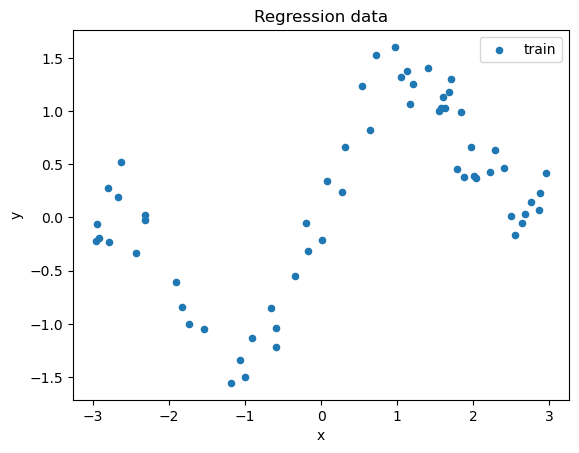

In [2]:
def load_xy(filename):
    data = np.loadtxt(DATA_DIR / filename, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1]

x_train, y_train = load_xy("train.csv")
x_valid, y_valid = load_xy("valid.csv")
x_test, y_test = load_xy("test.csv")

print("train:", x_train.shape, y_train.shape)
print("valid:", x_valid.shape, y_valid.shape)
print("test :", x_test.shape, y_test.shape)

plt.scatter(x_train, y_train, s=20, label="train")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression data")
plt.legend()
plt.show()


## Problem 1 — Normal equation

**课堂连接：** Lecture 2，线性模型与最小二乘。

使用 $\phi(x)=[1,x]$，令 $X\in\mathbb{R}^{m\times2}$。先在纸上从
$J(\theta)=\frac{1}{2m}\lVert X\theta-y\rVert^2$ 推导 normal equation，再实现函数。

**预期：** 返回 `(2,)` 的参数；训练和验证 MSE 都应明显小于直接预测均值的基线。

> **你的答案（请双击本格后填写）**
>
> TODO：写出从令梯度为零到 normal equation 的推导，并标注矩阵 shape。
损失函数为：

$$
J(\theta)=\frac{1}{2m}(X\theta-y)^T(X\theta-y)
$$

其中：

- $X\in\mathbb{R}^{m\times 2}$
- $\theta\in\mathbb{R}^{2}$
- $y\in\mathbb{R}^{m}$

对 $\theta$ 求梯度：

$$
\nabla_\theta J(\theta)
=
\frac{1}{m}X^T(X\theta-y)
$$

在损失函数的最小值处，梯度等于零：

$$
X^T(X\theta-y)=0
$$

展开：

$$
X^TX\theta-X^Ty=0
$$

因此：

$$
X^TX\theta=X^Ty
$$

程序需要求解的线性方程是：

$$
A\theta=b
$$

其中 $A=X^TX\in\mathbb{R}^{2\times2}$，
$b=X^Ty\in\mathbb{R}^{2}$，最终得到
$\theta\in\mathbb{R}^{2}$。

In [6]:
def add_intercept(x):
    return np.column_stack([np.ones_like(x), x])

def fit_normal_equation(X, y):
    # Fit theta without explicitly computing a matrix inverse.
    # START TODO
    A = X.T @ X
    b = X.T @ y
    theta = np.linalg.solve(A, b)
    return theta
    # END TODO

def mse(y_true, y_pred):
    # START TODO
    return np.mean((y_true - y_pred) ** 2)
    # END TODO


In [7]:
RUN_P1_CHECKS = True
if RUN_P1_CHECKS:
    X_train = add_intercept(x_train)
    X_valid = add_intercept(x_valid)
    theta_ne = fit_normal_equation(X_train, y_train)
    valid_pred = X_valid @ theta_ne
    baseline = np.full_like(y_valid, y_train.mean())
    print("theta:", theta_ne)
    print("valid MSE:", mse(y_valid, valid_pred))
    print("baseline MSE:", mse(y_valid, baseline))
    assert theta_ne.shape == (2,)
    assert mse(y_valid, valid_pred) < mse(y_valid, baseline)
else:
    print("P1 checks are off.")


theta: [0.1264 0.2168]
valid MSE: 0.534929046733952
baseline MSE: 0.8381072673881548


## Problem 2 — Gradient descent

**课堂连接：** Lecture 2，迭代优化。

1. 写出平方误差对 $\theta$ 的梯度。
2. 从全零参数开始更新。
3. 每 10 步保存一次 loss。
4. 将最终参数与 Problem 1 的 normal-equation 结果比较。

**预期：** loss 整体下降；足够迭代后，两种方法的参数应接近。

> **你的答案（请双击本格后填写）**
>
> TODO：写出一次 gradient-descent update，包括学习率。
$$
\theta = (X^TX)^{-1}(X^T)y
$$

$$
\nabla_\theta J(\theta)
=
\frac{1}{m}X^T(X\theta-y)
$$

$$
\theta \leftarrow \theta - \alpha \nabla_\theta J(\theta)
$$

In [30]:
def fit_gradient_descent(X, y, learning_rate=0.05, steps=1000):
    theta = np.zeros(X.shape[1])
    history = []
    for step in range(steps):
        # START TODO
        predictions = X @ theta
        errors = predictions - y
        gradient = (X.T @ errors) / len(y)
        theta -= learning_rate * gradient
        if step % 10 == 0:
            loss = mse(y, predictions)
            history.append(loss)
        # END TODO
    return theta, np.array(history)


GD theta: [0.1264 0.2168]
normal-equation theta: [0.1264 0.2168]


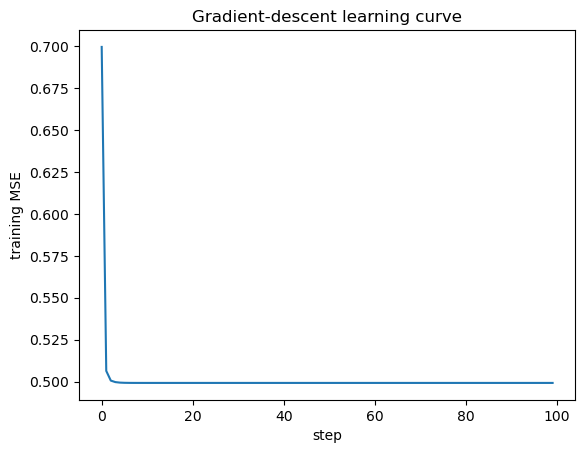

In [31]:
RUN_P2_CHECKS = True
if RUN_P2_CHECKS:
    theta_gd, history = fit_gradient_descent(add_intercept(x_train), y_train)
    print("GD theta:", theta_gd)
    print("normal-equation theta:", theta_ne)
    assert len(history) > 1 and history[-1] < history[0]
    assert np.allclose(theta_gd, theta_ne, atol=0.1)
    plt.plot(np.arange(len(history)), history)
    plt.xlabel("step")
    plt.ylabel("training MSE")
    plt.title("Gradient-descent learning curve")
    plt.show()
else:
    print("P2 checks are off. Run P1 first, then complete P2.")


## Problem 3 — Polynomial feature map

**题型来源：** CS229 problem sets 常用此实验展示模型容量与过拟合。

实现 $\phi_k(x)=[1,x,x^2,\ldots,x^k]$，分别拟合 `degree = 1, 3, 10`。
记录 train 和 valid MSE，并画出三条曲线。

**需要回答：** 哪个 degree 欠拟合？哪个可能过拟合？依据必须来自图和 MSE。

In [ ]:
def polynomial_features(x, degree):
    # Return shape (m, degree + 1), including the intercept column.
    # START TODO
    raise NotImplementedError("Build powers 0 through degree")
    # END TODO


In [ ]:
RUN_P3_CHECKS = False
if RUN_P3_CHECKS:
    grid = np.linspace(x_train.min(), x_train.max(), 400)
    for degree in (1, 3, 10):
        Phi_train = polynomial_features(x_train, degree)
        Phi_valid = polynomial_features(x_valid, degree)
        theta_poly = fit_normal_equation(Phi_train, y_train)
        train_mse = mse(y_train, Phi_train @ theta_poly)
        valid_mse = mse(y_valid, Phi_valid @ theta_poly)
        print(f"degree={degree:2d} train={train_mse:.4f} valid={valid_mse:.4f}")
        plt.plot(grid, polynomial_features(grid, degree) @ theta_poly, label=f"degree {degree}")
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5)
    plt.ylim(-3, 3)
    plt.legend()
    plt.title("Polynomial regression")
    plt.show()
else:
    print("P3 checks are off. Complete P1 first.")


> **你的答案（请双击本格后填写）**
>
> TODO：结合曲线和 train/valid MSE，判断欠拟合与过拟合。

## Problem 4 — Locally weighted regression

**课堂连接：** Lecture 3，LWR。

对每个查询点 $x$ 使用
$w^{(i)}=\exp(-(x^{(i)}-x)^2/(2\tau^2))$，再解加权 normal equation。

实现 `predict_lwr`，比较 $\tau\in\{0.1,0.5,2.0\}$ 的 validation MSE 和曲线。
**预期：** 很小的 $\tau$ 更弯曲，很大的 $\tau$ 更接近全局直线。

In [ ]:
def predict_lwr(x_train, y_train, x_query, tau):
    # Return one LWR prediction per query point.
    # START TODO
    raise NotImplementedError("Compute weights and solve one local model per query")
    # END TODO


In [ ]:
RUN_P4_CHECKS = False
if RUN_P4_CHECKS:
    grid = np.linspace(x_train.min(), x_train.max(), 300)
    for tau in (0.1, 0.5, 2.0):
        valid_pred = predict_lwr(x_train, y_train, x_valid, tau)
        print(f"tau={tau:.1f} valid MSE={mse(y_valid, valid_pred):.4f}")
        plt.plot(grid, predict_lwr(x_train, y_train, grid, tau), label=f"tau={tau}")
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5)
    plt.legend()
    plt.title("Locally weighted regression")
    plt.show()
else:
    print("P4 checks are off.")


> **你的答案（请双击本格后填写）**
>
> TODO：解释 tau 如何改变 bias/variance；引用你实际得到的曲线和 valid MSE。

## Checks

- [ ] 所有设计矩阵的第一列都是 1。
- [ ] 没有显式计算矩阵逆；使用 `np.linalg.solve`。
- [ ] gradient descent 与 normal equation 得到接近的参数。
- [ ] 对 polynomial degree 和 LWR tau 的判断来自验证集，不来自测试集。

## Next Steps

完成 PS1 后再进入分类；不要提前使用分类指标解释回归模型。